Selected videos:
Known Route 1: route_1.mp4
Known Route 2: route_2.mp4
Query Route: query_unknown_route.mp4

✅ Frame extraction complete.
{
  "route_1": {
    "video": "route_1.mp4",
    "fps": 30.0,
    "original_duration_seconds": 21.733333333333334,
    "used_duration_seconds": 20,
    "saved_frames": 50,
    "output_folder": "vxn_extracted_frames\\known_routes\\route_1"
  },
  "route_2": {
    "video": "route_2.mp4",
    "fps": 30.0,
    "original_duration_seconds": 19.1,
    "used_duration_seconds": 19.1,
    "saved_frames": 50,
    "output_folder": "vxn_extracted_frames\\known_routes\\route_2"
  },
  "query_unknown_route": {
    "video": "query_unknown_route.mp4",
    "fps": 30.0,
    "original_duration_seconds": 21.433333333333334,
    "used_duration_seconds": 20,
    "saved_frames": 50,
    "output_folder": "vxn_extracted_frames\\query_unknown_route"
  }
}


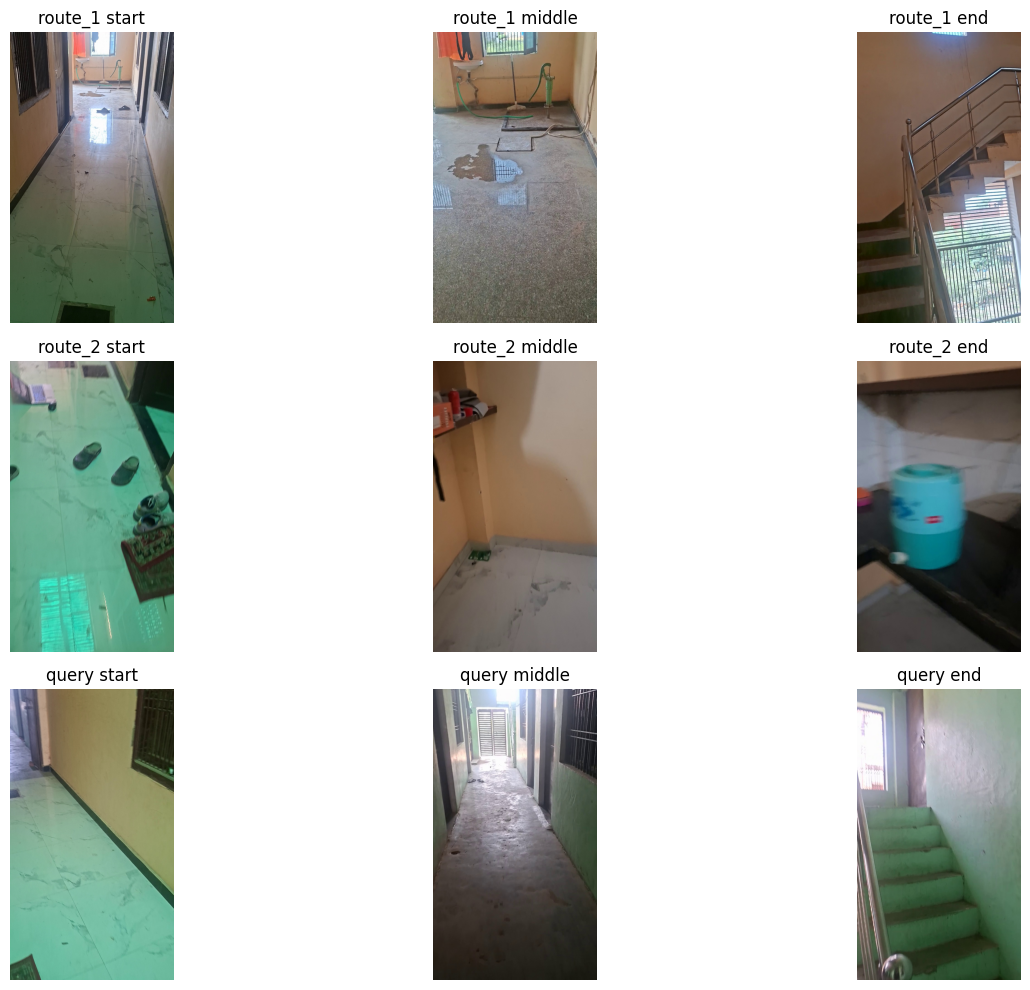

In [4]:
# ============================================================
# CELL 1: SETUP + VIDEO FRAME EXTRACTION
# VXN-RAMNet Unknown Route Auto-Learning System
#
# Known memory routes:
#   route_1.mp4
#   route_2.mp4
#
# Query/test unknown route:
#   query_unknown_route.mp4
#
# If query route is unknown, later cells will auto-save it as route_3.
# ============================================================

import sys
import subprocess
from pathlib import Path
import shutil
import json
import time

def install_if_missing(package_name, import_name=None):
    try:
        __import__(import_name or package_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

install_if_missing("opencv-python", "cv2")
install_if_missing("tensorflow", "tensorflow")
install_if_missing("pillow", "PIL")
install_if_missing("numpy", "numpy")
install_if_missing("pandas", "pandas")
install_if_missing("matplotlib", "matplotlib")

import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

ROOT_DIR = Path(".")
VIDEOS_DIR = ROOT_DIR / "videos"

EXTRACTED_DIR = ROOT_DIR / "vxn_extracted_frames"
KNOWN_ROUTES_DIR = EXTRACTED_DIR / "known_routes"
QUERY_DIR = EXTRACTED_DIR / "query_unknown_route"

MAX_VIDEO_SECONDS = 20
ROUTE_MEMORY_FRAMES = 50
QUERY_EVIDENCE_FRAMES = 50

VIDEO_EXTENSIONS = [".mp4", ".mov", ".avi", ".mkv", ".webm"]

# Recommended filenames
ROUTE_1_VIDEO = "route_1.mp4"
ROUTE_2_VIDEO = "route_2.mp4"
QUERY_VIDEO = "query_unknown_route.mp4"

# If your filenames are different, change these names above.


# ------------------------------------------------------------
# FIND VIDEO FILES
# ------------------------------------------------------------

def find_video(filename):
    candidates = [
        VIDEOS_DIR / filename,
        ROOT_DIR / filename
    ]
    for path in candidates:
        if path.exists():
            return path
    return None

route_1_path = find_video(ROUTE_1_VIDEO)
route_2_path = find_video(ROUTE_2_VIDEO)
query_path = find_video(QUERY_VIDEO)

# Auto fallback: first 2 videos = known routes, third = query
if route_1_path is None or route_2_path is None or query_path is None:
    print("Manual filenames not fully found. Trying auto-detect fallback...")

    search_dirs = []
    if VIDEOS_DIR.exists():
        search_dirs.append(VIDEOS_DIR)
    search_dirs.append(ROOT_DIR)

    all_videos = []
    for folder in search_dirs:
        for file in folder.iterdir():
            if file.is_file() and file.suffix.lower() in VIDEO_EXTENSIONS:
                all_videos.append(file)

    all_videos = sorted(list(set(all_videos)))

    if len(all_videos) < 3:
        raise FileNotFoundError(
            "Need at least 3 videos:\n"
            "videos/route_1.mp4\n"
            "videos/route_2.mp4\n"
            "videos/query_unknown_route.mp4"
        )

    route_1_path = all_videos[0]
    route_2_path = all_videos[1]
    query_path = all_videos[2]

print("Selected videos:")
print("Known Route 1:", route_1_path)
print("Known Route 2:", route_2_path)
print("Query Route:", query_path)


# ------------------------------------------------------------
# CLEAN OUTPUT
# ------------------------------------------------------------

if EXTRACTED_DIR.exists():
    shutil.rmtree(EXTRACTED_DIR)

(KNOWN_ROUTES_DIR / "route_1").mkdir(parents=True, exist_ok=True)
(KNOWN_ROUTES_DIR / "route_2").mkdir(parents=True, exist_ok=True)
QUERY_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# VIDEO HELPERS
# ------------------------------------------------------------

def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps <= 0:
        fps = 30.0

    duration = total_frames / fps if fps > 0 else 0

    cap.release()

    return {
        "fps": fps,
        "total_frames": total_frames,
        "duration_seconds": duration
    }

def extract_even_frames(video_path, output_folder, frame_count, max_seconds=20):
    output_folder.mkdir(parents=True, exist_ok=True)

    info = get_video_info(video_path)

    fps = info["fps"]
    duration = info["duration_seconds"]
    total_frames = info["total_frames"]

    usable_seconds = min(duration, max_seconds)
    usable_frames = int(usable_seconds * fps)
    usable_frames = min(usable_frames, total_frames)

    if usable_frames <= 0:
        raise ValueError(f"No usable frames in video: {video_path}")

    frame_indices = np.linspace(
        0,
        max(0, usable_frames - 1),
        frame_count,
        dtype=int
    )

    cap = cv2.VideoCapture(str(video_path))
    saved_paths = []

    for idx, frame_index in enumerate(frame_indices, start=1):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
        success, frame = cap.read()

        if not success:
            continue

        out_path = output_folder / f"frame_{idx:03d}.jpg"
        cv2.imwrite(str(out_path), frame)
        saved_paths.append(out_path)

    cap.release()

    return {
        "video": str(video_path),
        "fps": fps,
        "original_duration_seconds": duration,
        "used_duration_seconds": usable_seconds,
        "saved_frames": len(saved_paths),
        "output_folder": str(output_folder)
    }


# ------------------------------------------------------------
# EXTRACT FRAMES
# ------------------------------------------------------------

reports = {}

reports["route_1"] = extract_even_frames(
    route_1_path,
    KNOWN_ROUTES_DIR / "route_1",
    ROUTE_MEMORY_FRAMES,
    MAX_VIDEO_SECONDS
)

reports["route_2"] = extract_even_frames(
    route_2_path,
    KNOWN_ROUTES_DIR / "route_2",
    ROUTE_MEMORY_FRAMES,
    MAX_VIDEO_SECONDS
)

reports["query_unknown_route"] = extract_even_frames(
    query_path,
    QUERY_DIR,
    QUERY_EVIDENCE_FRAMES,
    MAX_VIDEO_SECONDS
)

report_path = EXTRACTED_DIR / "extraction_report.json"

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(reports, f, indent=2)

print("\n✅ Frame extraction complete.")
print(json.dumps(reports, indent=2))


# ------------------------------------------------------------
# PREVIEW
# ------------------------------------------------------------

preview_items = []

for route_name in ["route_1", "route_2"]:
    frames = sorted((KNOWN_ROUTES_DIR / route_name).glob("*.jpg"))
    preview_items.append((frames[0], f"{route_name} start"))
    preview_items.append((frames[len(frames)//2], f"{route_name} middle"))
    preview_items.append((frames[-1], f"{route_name} end"))

query_frames = sorted(QUERY_DIR.glob("*.jpg"))
preview_items.append((query_frames[0], "query start"))
preview_items.append((query_frames[len(query_frames)//2], "query middle"))
preview_items.append((query_frames[-1], "query end"))

plt.figure(figsize=(15, 10))

for i, (img_path, title) in enumerate(preview_items, start=1):
    img = Image.open(img_path).convert("RGB")
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# CELL 2: BUILD KNOWN ROUTE MEMORY
# Known routes:
#   route_1
#   route_2
#
# Saves:
#   vxn_route_memory.npz
#   vxn_route_metadata.json
# ============================================================

from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
from PIL import Image, ImageOps

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

ROOT_DIR = Path(".")
EXTRACTED_DIR = ROOT_DIR / "vxn_extracted_frames"
KNOWN_ROUTES_DIR = EXTRACTED_DIR / "known_routes"

MEMORY_NPZ = ROOT_DIR / "vxn_route_memory.npz"
METADATA_JSON = ROOT_DIR / "vxn_route_metadata.json"

MODEL_INPUT_SIZE = (224, 224)
BATCH_SIZE = 16
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]

route_folders = [
    KNOWN_ROUTES_DIR / "route_1",
    KNOWN_ROUTES_DIR / "route_2"
]

for folder in route_folders:
    if not folder.exists():
        raise FileNotFoundError(f"Missing route folder: {folder}. Run Cell 1 first.")

route_names = []
image_paths = []
labels = []

for route_idx, folder in enumerate(route_folders):
    route_names.append(folder.name)

    frames = sorted([
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    if len(frames) == 0:
        raise FileNotFoundError(f"No frames found in {folder}")

    print(f"{folder.name}: {len(frames)} frames")

    for frame_path in frames:
        image_paths.append(frame_path)
        labels.append(route_idx)

labels = np.array(labels, dtype=np.int32)

print("\nTotal known route frames:", len(image_paths))
print("Known routes:", route_names)


# ------------------------------------------------------------
# LOAD MODEL ONCE
# ------------------------------------------------------------

print("\nLoading EfficientNetB0 frozen encoder...")

encoder = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

encoder.trainable = False

dummy = np.zeros((1, 224, 224, 3), dtype=np.float32)
_ = encoder.predict(dummy, verbose=0)

print("✅ Encoder loaded and warmed up.")


# ------------------------------------------------------------
# FAST ENCODING HELPERS
# ------------------------------------------------------------

def load_image_fast(img_path):
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    img = img.resize(MODEL_INPUT_SIZE)
    arr = keras_image.img_to_array(img)
    return arr

def l2_normalize_matrix(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return x / norms

def build_batches(paths, batch_size=BATCH_SIZE):
    batch = []
    batch_paths = []

    for path in paths:
        batch.append(load_image_fast(path))
        batch_paths.append(str(path.as_posix()))

        if len(batch) == batch_size:
            batch_np = np.array(batch, dtype=np.float32)
            batch_np = preprocess_input(batch_np)
            yield batch_np, batch_paths
            batch = []
            batch_paths = []

    if batch:
        batch_np = np.array(batch, dtype=np.float32)
        batch_np = preprocess_input(batch_np)
        yield batch_np, batch_paths


# ------------------------------------------------------------
# ENCODE KNOWN ROUTES
# ------------------------------------------------------------

all_embeddings = []
all_paths_text = []

start = time.time()
processed = 0

for batch_np, batch_paths in build_batches(image_paths):
    emb = encoder.predict(batch_np, verbose=0).astype(np.float32)
    emb = l2_normalize_matrix(emb)

    all_embeddings.append(emb)
    all_paths_text.extend(batch_paths)

    processed += len(batch_paths)
    print(f"Encoded {processed}/{len(image_paths)} frames")

embeddings = np.vstack(all_embeddings).astype(np.float32)

encode_time = time.time() - start

print("\n✅ Known route encoding complete.")
print("Embeddings:", embeddings.shape)
print(f"Encoding time: {encode_time:.2f} sec")
print(f"Average per frame: {(encode_time / len(image_paths)) * 1000:.2f} ms")


# ------------------------------------------------------------
# CREATE CENTROIDS
# ------------------------------------------------------------

centroids = []

for route_idx in range(len(route_names)):
    route_embs = embeddings[labels == route_idx]
    centroid = np.mean(route_embs, axis=0, keepdims=True)
    centroid = l2_normalize_matrix(centroid)[0]
    centroids.append(centroid)

centroids = np.vstack(centroids).astype(np.float32)

np.savez_compressed(
    MEMORY_NPZ,
    embeddings=embeddings,
    labels=labels,
    centroids=centroids,
    route_names=np.array(route_names),
    image_paths=np.array(all_paths_text)
)

metadata = {
    "system": "VXN-RAMNet",
    "architecture": "unknown_route_auto_learning",
    "stage": "known_route_memory",
    "gps_used": False,
    "model_retraining_used": False,
    "model": "EfficientNetB0",
    "routes": route_names,
    "total_routes": len(route_names),
    "total_frames": len(image_paths),
    "created_at_unix": time.time()
}

with open(METADATA_JSON, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("\n✅ Known route memory saved.")
print("Memory:", MEMORY_NPZ.resolve())
print("Metadata:", METADATA_JSON.resolve())
print("\nCurrent known routes:", route_names)

route_1: 50 frames
route_2: 50 frames

Total known route frames: 100
Known routes: ['route_1', 'route_2']

Loading EfficientNetB0 frozen encoder...
✅ Encoder loaded and warmed up.
Encoded 16/100 frames
Encoded 32/100 frames
Encoded 48/100 frames
Encoded 64/100 frames
Encoded 80/100 frames
Encoded 96/100 frames
Encoded 100/100 frames

✅ Known route encoding complete.
Embeddings: (100, 1280)
Encoding time: 4.40 sec
Average per frame: 44.00 ms

✅ Known route memory saved.
Memory: C:\Users\progr\JupyterNotebook\Untitled Folder\vxn_route_memory.npz
Metadata: C:\Users\progr\JupyterNotebook\Untitled Folder\vxn_route_metadata.json

Current known routes: ['route_1', 'route_2']


Known routes: ['route_1', 'route_2']
Query frames: 50

Loading EfficientNetB0 frozen encoder...
✅ Encoder ready.

Evidence frames: 1
State: CONFIRMED_KNOWN_ROUTE
Prediction: route_1
Best score: 0.7053
Gap: 0.103
Stability: 1.0
Reason: Known route confirmed

Evidence frames: 3
State: UNKNOWN_ROUTE
Prediction: UNKNOWN_ROUTE
Best score: 0.5745
Gap: 0.1745
Stability: 1.0
Reason: Best route score is below known-route threshold

Evidence frames: 5
State: UNKNOWN_ROUTE
Prediction: UNKNOWN_ROUTE
Best score: 0.5792
Gap: 0.1793
Stability: 1.0
Reason: Best route score is below known-route threshold

PROGRESSIVE QUERY REPORT


,evidence_frames,state,prediction,best_score,gap,stability,inference_ms,scoring_ms,total_ms,reason
0,1,CONFIRMED_KNOWN_ROUTE,route_1,0.705334,0.103034,1.0,93.568802,0.00000,93.568802,Known route confirmed
1,3,UNKNOWN_ROUTE,UNKNOWN_ROUTE,0.574456,0.174494,1.0,1514.239073,1.46246,1515.701532,Best route score is below known-route threshold
2,5,UNKNOWN_ROUTE,UNKNOWN_ROUTE,0.579176,0.179274,1.0,147.619247,0.00000,147.619247,Best route score is below known-route threshold



FINAL AGGREGATED SCORES


,route,average_score,max_score,rank1_votes,stability
0,route_1,0.579176,0.705334,5,1.0
1,route_2,0.399902,0.602300,0,0.0



FINAL DECISION
{'state': 'UNKNOWN_ROUTE', 'prediction': 'UNKNOWN_ROUTE', 'reason': 'Best route score is below known-route threshold', 'best_score': 0.5791764432191849, 'gap': 0.1792744755744935, 'stability': 1.0}

Decision saved: C:\Users\progr\JupyterNotebook\Untitled Folder\vxn_unknown_route_decision.json


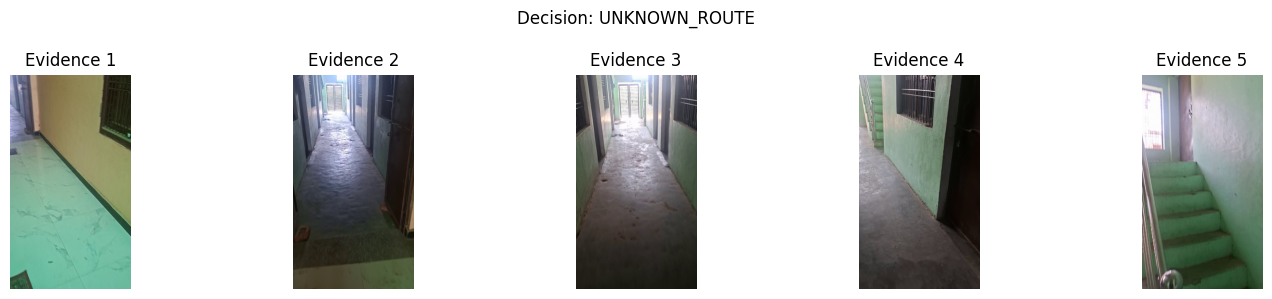

In [6]:
# ============================================================
# CELL 3: QUERY ROUTE CLASSIFICATION AGAINST KNOWN ROUTES
#
# Known routes:
#   route_1
#   route_2
#
# Query:
#   third video frames
#
# Expected:
#   UNKNOWN_ROUTE if query is different from route_1 and route_2.
# ============================================================

from pathlib import Path
import time
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

ROOT_DIR = Path(".")
EXTRACTED_DIR = ROOT_DIR / "vxn_extracted_frames"
QUERY_DIR = EXTRACTED_DIR / "query_unknown_route"

MEMORY_NPZ = ROOT_DIR / "vxn_route_memory.npz"

MODEL_INPUT_SIZE = (224, 224)
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]

# Evidence strategy
EVIDENCE_FRAME_COUNTS = [1, 3, 5, 7, 9]

# Important:
# These thresholds make UNKNOWN possible.
# Tune slightly based on your environment.
MIN_AVERAGE_ROUTE_SCORE = 0.70
MIN_CONFIDENCE_GAP = 0.035
MIN_STABILITY = 0.60

if not MEMORY_NPZ.exists():
    raise FileNotFoundError("Memory file not found. Run Cell 2 first.")

if not QUERY_DIR.exists():
    raise FileNotFoundError("Query frames not found. Run Cell 1 first.")

memory = np.load(MEMORY_NPZ, allow_pickle=True)

memory_embeddings = memory["embeddings"].astype(np.float32)
memory_labels = memory["labels"].astype(np.int32)
route_centroids = memory["centroids"].astype(np.float32)
route_names = memory["route_names"].tolist()
memory_image_paths = memory["image_paths"].tolist()

query_frames = sorted([
    p for p in QUERY_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

print("Known routes:", route_names)
print("Query frames:", len(query_frames))

# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

print("\nLoading EfficientNetB0 frozen encoder...")

encoder = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

encoder.trainable = False

dummy = np.zeros((1, 224, 224, 3), dtype=np.float32)
_ = encoder.predict(dummy, verbose=0)

print("✅ Encoder ready.")


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def l2_normalize_matrix(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return x / norms

def load_image_fast(img_path):
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    img = img.resize(MODEL_INPUT_SIZE)
    arr = keras_image.img_to_array(img)
    return arr

def select_even_frames(frames, count):
    if count >= len(frames):
        return frames
    idxs = np.linspace(0, len(frames) - 1, count, dtype=int)
    return [frames[i] for i in idxs]

def embed_frames(frames):
    batch = np.array([load_image_fast(p) for p in frames], dtype=np.float32)
    batch = preprocess_input(batch)

    t0 = time.time()
    emb = encoder.predict(batch, verbose=0).astype(np.float32)
    infer_ms = (time.time() - t0) * 1000

    emb = l2_normalize_matrix(emb)
    return emb, infer_ms

def score_one_embedding(test_embedding):
    all_scores = memory_embeddings @ test_embedding
    centroid_scores = route_centroids @ test_embedding

    route_results = []

    for route_idx, route_name in enumerate(route_names):
        route_scores = all_scores[memory_labels == route_idx]
        sorted_scores = np.sort(route_scores)[::-1]

        best = float(sorted_scores[0])
        top3 = float(np.mean(sorted_scores[:min(3, len(sorted_scores))]))
        centroid = float(centroid_scores[route_idx])

        final_score = 0.50 * best + 0.30 * top3 + 0.20 * centroid

        route_results.append({
            "route": route_name,
            "best_similarity": best,
            "top3_mean": top3,
            "centroid_similarity": centroid,
            "final_score": final_score
        })

    return sorted(route_results, key=lambda x: x["final_score"], reverse=True)

def aggregate_results(frame_results_list):
    score_history = {name: [] for name in route_names}
    votes = {name: 0 for name in route_names}

    for results in frame_results_list:
        votes[results[0]["route"]] += 1
        for r in results:
            score_history[r["route"]].append(r["final_score"])

    total = len(frame_results_list)

    aggregated = []

    for route in route_names:
        scores = score_history[route]
        aggregated.append({
            "route": route,
            "average_score": float(np.mean(scores)),
            "max_score": float(np.max(scores)),
            "rank1_votes": votes[route],
            "stability": votes[route] / total
        })

    return sorted(aggregated, key=lambda x: x["average_score"], reverse=True)

def decide_known_unknown(aggregated):
    best = aggregated[0]
    second = aggregated[1] if len(aggregated) > 1 else None

    best_score = best["average_score"]
    second_score = second["average_score"] if second else 0.0
    gap = best_score - second_score
    stability = best["stability"]

    if best_score < MIN_AVERAGE_ROUTE_SCORE:
        return {
            "state": "UNKNOWN_ROUTE",
            "prediction": "UNKNOWN_ROUTE",
            "reason": "Best route score is below known-route threshold",
            "best_score": best_score,
            "gap": gap,
            "stability": stability
        }

    if gap < MIN_CONFIDENCE_GAP:
        return {
            "state": "UNCERTAIN_ROUTE",
            "prediction": "UNCERTAIN_ROUTE",
            "reason": "Known routes are too close",
            "best_score": best_score,
            "gap": gap,
            "stability": stability
        }

    if stability < MIN_STABILITY:
        return {
            "state": "UNCERTAIN_ROUTE",
            "prediction": "UNCERTAIN_ROUTE",
            "reason": "Route vote stability is low",
            "best_score": best_score,
            "gap": gap,
            "stability": stability
        }

    return {
        "state": "CONFIRMED_KNOWN_ROUTE",
        "prediction": best["route"],
        "reason": "Known route confirmed",
        "best_score": best_score,
        "gap": gap,
        "stability": stability
    }


# ------------------------------------------------------------
# RUN PROGRESSIVE QUERY TEST
# ------------------------------------------------------------

progress_reports = []
final_decision = None
final_aggregated = None
final_selected_frames = None

for count in EVIDENCE_FRAME_COUNTS:
    selected = select_even_frames(query_frames, count)
    embeddings, infer_ms = embed_frames(selected)

    scoring_start = time.time()

    frame_results_list = [score_one_embedding(emb) for emb in embeddings]
    aggregated = aggregate_results(frame_results_list)
    decision = decide_known_unknown(aggregated)

    scoring_ms = (time.time() - scoring_start) * 1000

    progress_reports.append({
        "evidence_frames": count,
        "state": decision["state"],
        "prediction": decision["prediction"],
        "best_score": decision["best_score"],
        "gap": decision["gap"],
        "stability": decision["stability"],
        "inference_ms": infer_ms,
        "scoring_ms": scoring_ms,
        "total_ms": infer_ms + scoring_ms,
        "reason": decision["reason"]
    })

    print("\nEvidence frames:", count)
    print("State:", decision["state"])
    print("Prediction:", decision["prediction"])
    print("Best score:", round(decision["best_score"], 4))
    print("Gap:", round(decision["gap"], 4))
    print("Stability:", round(decision["stability"], 4))
    print("Reason:", decision["reason"])

    final_decision = decision
    final_aggregated = aggregated
    final_selected_frames = selected

    if decision["state"] in ["CONFIRMED_KNOWN_ROUTE", "UNKNOWN_ROUTE"] and count >= 5:
        break

progress_df = pd.DataFrame(progress_reports)
aggregated_df = pd.DataFrame(final_aggregated)

print("\n==============================")
print("PROGRESSIVE QUERY REPORT")
print("==============================")
display(progress_df)

print("\n==============================")
print("FINAL AGGREGATED SCORES")
print("==============================")
display(aggregated_df)

print("\n==============================")
print("FINAL DECISION")
print("==============================")
print(final_decision)

# Save decision for next cell
UNKNOWN_DECISION_FILE = ROOT_DIR / "vxn_unknown_route_decision.json"

with open(UNKNOWN_DECISION_FILE, "w", encoding="utf-8") as f:
    json.dump({
        "decision": final_decision,
        "progress_reports": progress_reports,
        "final_aggregated": final_aggregated,
        "query_frames_folder": str(QUERY_DIR.as_posix()),
        "selected_frames": [str(p.as_posix()) for p in final_selected_frames],
        "created_at_unix": time.time()
    }, f, indent=2)

print("\nDecision saved:", UNKNOWN_DECISION_FILE.resolve())

# Preview selected evidence frames
plt.figure(figsize=(15, 3))
for i, frame_path in enumerate(final_selected_frames[:5], start=1):
    img = Image.open(frame_path).convert("RGB")
    plt.subplot(1, min(5, len(final_selected_frames)), i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Evidence {i}")
plt.suptitle(f"Decision: {final_decision['state']}")
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# CELL 4: AUTO-LEARN UNKNOWN ROUTE AS NEW ROUTE
#
# If Cell 3 says UNKNOWN_ROUTE:
#   query route becomes route_3
#   route_3 is added into route memory
#
# This is the automatic unknown-route learning architecture.
# ============================================================

from pathlib import Path
import json
import time
import shutil
import numpy as np
import pandas as pd
from PIL import Image, ImageOps

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

ROOT_DIR = Path(".")
EXTRACTED_DIR = ROOT_DIR / "vxn_extracted_frames"
KNOWN_ROUTES_DIR = EXTRACTED_DIR / "known_routes"
QUERY_DIR = EXTRACTED_DIR / "query_unknown_route"

MEMORY_NPZ = ROOT_DIR / "vxn_route_memory.npz"
METADATA_JSON = ROOT_DIR / "vxn_route_metadata.json"
UNKNOWN_DECISION_FILE = ROOT_DIR / "vxn_unknown_route_decision.json"

UPDATED_MEMORY_NPZ = ROOT_DIR / "vxn_route_memory_updated.npz"
UPDATED_METADATA_JSON = ROOT_DIR / "vxn_route_metadata_updated.json"

MODEL_INPUT_SIZE = (224, 224)
BATCH_SIZE = 16
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]

if not UNKNOWN_DECISION_FILE.exists():
    raise FileNotFoundError("Run Cell 3 first.")

with open(UNKNOWN_DECISION_FILE, "r", encoding="utf-8") as f:
    unknown_data = json.load(f)

decision_state = unknown_data["decision"]["state"]

print("Previous decision state:", decision_state)

if decision_state != "UNKNOWN_ROUTE":
    print("\nRoute is not UNKNOWN_ROUTE.")
    print("Auto-learning is skipped for safety.")
    print("If you still want to force learn this query as a new route, set FORCE_LEARN = True.")

FORCE_LEARN = False

if decision_state != "UNKNOWN_ROUTE" and not FORCE_LEARN:
    raise SystemExit("Stopped: Query was not UNKNOWN_ROUTE. Nothing to auto-learn.")

# ------------------------------------------------------------
# COPY QUERY FRAMES INTO NEW ROUTE FOLDER
# ------------------------------------------------------------

new_route_name = "route_3"
new_route_folder = KNOWN_ROUTES_DIR / new_route_name

if new_route_folder.exists():
    shutil.rmtree(new_route_folder)

new_route_folder.mkdir(parents=True, exist_ok=True)

query_frames = sorted([
    p for p in QUERY_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

if len(query_frames) == 0:
    raise FileNotFoundError("No query frames found to learn.")

for idx, frame_path in enumerate(query_frames, start=1):
    out_path = new_route_folder / f"frame_{idx:03d}.jpg"
    shutil.copy2(frame_path, out_path)

print(f"\n✅ Unknown route frames copied into: {new_route_folder}")
print("Frames learned:", len(query_frames))


# ------------------------------------------------------------
# LOAD EXISTING MEMORY
# ------------------------------------------------------------

memory = np.load(MEMORY_NPZ, allow_pickle=True)

old_embeddings = memory["embeddings"].astype(np.float32)
old_labels = memory["labels"].astype(np.int32)
old_centroids = memory["centroids"].astype(np.float32)
old_route_names = memory["route_names"].tolist()
old_image_paths = memory["image_paths"].tolist()

if new_route_name in old_route_names:
    raise ValueError(f"{new_route_name} already exists in memory.")

new_route_index = len(old_route_names)

print("\nExisting routes:", old_route_names)
print("New route index:", new_route_index)


# ------------------------------------------------------------
# LOAD ENCODER
# ------------------------------------------------------------

print("\nLoading EfficientNetB0 frozen encoder...")

encoder = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

encoder.trainable = False

dummy = np.zeros((1, 224, 224, 3), dtype=np.float32)
_ = encoder.predict(dummy, verbose=0)

print("✅ Encoder ready.")


# ------------------------------------------------------------
# ENCODING HELPERS
# ------------------------------------------------------------

def load_image_fast(img_path):
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    img = img.resize(MODEL_INPUT_SIZE)
    arr = keras_image.img_to_array(img)
    return arr

def l2_normalize_matrix(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return x / norms

def build_batches(paths, batch_size=BATCH_SIZE):
    batch = []
    batch_paths = []

    for path in paths:
        batch.append(load_image_fast(path))
        batch_paths.append(str(path.as_posix()))

        if len(batch) == batch_size:
            batch_np = np.array(batch, dtype=np.float32)
            batch_np = preprocess_input(batch_np)
            yield batch_np, batch_paths
            batch = []
            batch_paths = []

    if batch:
        batch_np = np.array(batch, dtype=np.float32)
        batch_np = preprocess_input(batch_np)
        yield batch_np, batch_paths


# ------------------------------------------------------------
# ENCODE NEW ROUTE
# ------------------------------------------------------------

new_route_frames = sorted([
    p for p in new_route_folder.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

new_embeddings_list = []
new_paths_text = []

start = time.time()
processed = 0

for batch_np, batch_paths in build_batches(new_route_frames):
    emb = encoder.predict(batch_np, verbose=0).astype(np.float32)
    emb = l2_normalize_matrix(emb)

    new_embeddings_list.append(emb)
    new_paths_text.extend(batch_paths)

    processed += len(batch_paths)
    print(f"Encoded route_3 frames: {processed}/{len(new_route_frames)}")

new_embeddings = np.vstack(new_embeddings_list).astype(np.float32)

encoding_time = time.time() - start

print("\n✅ New route encoded.")
print("New route embeddings:", new_embeddings.shape)
print(f"Encoding time: {encoding_time:.2f} sec")


# ------------------------------------------------------------
# UPDATE MEMORY
# ------------------------------------------------------------

new_labels = np.full(
    shape=(new_embeddings.shape[0],),
    fill_value=new_route_index,
    dtype=np.int32
)

updated_embeddings = np.vstack([old_embeddings, new_embeddings]).astype(np.float32)
updated_labels = np.concatenate([old_labels, new_labels]).astype(np.int32)

updated_route_names = old_route_names + [new_route_name]
updated_image_paths = old_image_paths + new_paths_text

# Recalculate all centroids from updated memory
updated_centroids = []

for route_idx in range(len(updated_route_names)):
    route_embs = updated_embeddings[updated_labels == route_idx]
    centroid = np.mean(route_embs, axis=0, keepdims=True)
    centroid = l2_normalize_matrix(centroid)[0]
    updated_centroids.append(centroid)

updated_centroids = np.vstack(updated_centroids).astype(np.float32)

np.savez_compressed(
    UPDATED_MEMORY_NPZ,
    embeddings=updated_embeddings,
    labels=updated_labels,
    centroids=updated_centroids,
    route_names=np.array(updated_route_names),
    image_paths=np.array(updated_image_paths)
)

metadata = {
    "system": "VXN-RAMNet",
    "architecture": "unknown_route_auto_learning",
    "stage": "updated_route_memory_after_unknown_learning",
    "gps_used": False,
    "model_retraining_used": False,
    "model": "EfficientNetB0",
    "old_routes": old_route_names,
    "new_route_added": new_route_name,
    "updated_routes": updated_route_names,
    "total_routes": len(updated_route_names),
    "total_frames": int(updated_embeddings.shape[0]),
    "new_route_frames": int(new_embeddings.shape[0]),
    "created_at_unix": time.time(),
    "note": "Unknown query route was converted into a new known route without retraining."
}

with open(UPDATED_METADATA_JSON, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("\n✅ Updated memory saved.")
print("Updated memory:", UPDATED_MEMORY_NPZ.resolve())
print("Updated metadata:", UPDATED_METADATA_JSON.resolve())

print("\nFinal known routes:", updated_route_names)
print("\nImportant:")
print("No retraining happened.")
print("The unknown route became a new route by storing embeddings only.")

Previous decision state: UNKNOWN_ROUTE

✅ Unknown route frames copied into: vxn_extracted_frames\known_routes\route_3
Frames learned: 50

Existing routes: ['route_1', 'route_2']
New route index: 2

Loading EfficientNetB0 frozen encoder...
✅ Encoder ready.
Encoded route_3 frames: 16/50
Encoded route_3 frames: 32/50
Encoded route_3 frames: 48/50
Encoded route_3 frames: 50/50

✅ New route encoded.
New route embeddings: (50, 1280)
Encoding time: 3.01 sec

✅ Updated memory saved.
Updated memory: C:\Users\progr\JupyterNotebook\Untitled Folder\vxn_route_memory_updated.npz
Updated metadata: C:\Users\progr\JupyterNotebook\Untitled Folder\vxn_route_metadata_updated.json

Final known routes: ['route_1', 'route_2', 'route_3']

Important:
No retraining happened.
The unknown route became a new route by storing embeddings only.


Known routes after learning: ['route_1', 'route_2', 'route_3']
Query frames: 50

Loading EfficientNetB0 frozen encoder...
✅ Encoder ready.

Evidence frames: 1
State: CONFIRMED_ROUTE
Prediction: route_3
Best score: 0.8984
Gap: 0.1931
Stability: 1.0
Reason: Known route confirmed

Evidence frames: 3
State: CONFIRMED_ROUTE
Prediction: route_3
Best score: 0.9119
Gap: 0.3375
Stability: 1.0
Reason: Known route confirmed

FOLLOW-UP ROUTE TEST REPORT


,evidence_frames,state,prediction,best_score,gap,stability,inference_ms,scoring_ms,total_ms,reason
0,1,CONFIRMED_ROUTE,route_3,0.898443,0.193109,1.0,111.863852,1.002073,112.865925,Known route confirmed
1,3,CONFIRMED_ROUTE,route_3,0.911926,0.337471,1.0,1573.857307,1.913786,1575.771093,Known route confirmed



FINAL AGGREGATED ROUTE SCORES


,route,average_score,max_score,rank1_votes,stability
0,route_3,0.911926,0.971655,3,1.0
1,route_1,0.574456,0.705334,0,0.0
2,route_2,0.399962,0.602300,0,0.0



FINAL DECISION AFTER LEARNING
{'state': 'CONFIRMED_ROUTE', 'prediction': 'route_3', 'reason': 'Known route confirmed', 'best_score': 0.9119264384110769, 'gap': 0.33747067153453836, 'stability': 1.0}

✅ SUCCESS: The previously unknown route is now recognized as route_3.


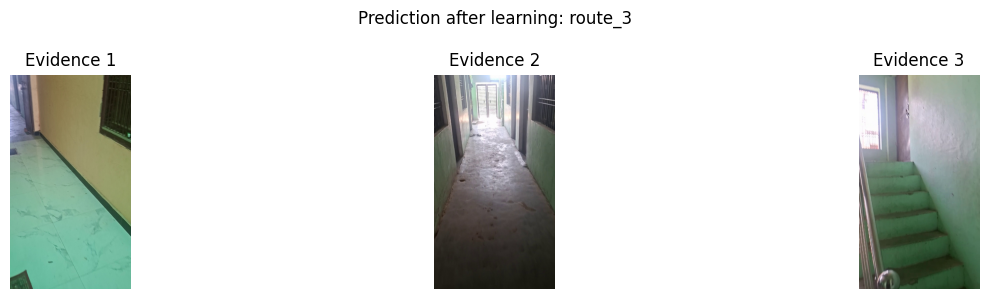

In [8]:
# ============================================================
# CELL 5: FOLLOW-UP TEST AFTER UNKNOWN ROUTE LEARNING
#
# Now route_3 has been added to memory.
# The same query video should classify as route_3.
# ============================================================

from pathlib import Path
import time
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

ROOT_DIR = Path(".")
EXTRACTED_DIR = ROOT_DIR / "vxn_extracted_frames"
QUERY_DIR = EXTRACTED_DIR / "query_unknown_route"

UPDATED_MEMORY_NPZ = ROOT_DIR / "vxn_route_memory_updated.npz"

MODEL_INPUT_SIZE = (224, 224)
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]

EVIDENCE_FRAME_COUNTS = [1, 3, 5, 7, 9]

MIN_ROUTE_SCORE = 0.70
MIN_CONFIDENCE_GAP = 0.035
MIN_STABILITY = 0.60

if not UPDATED_MEMORY_NPZ.exists():
    raise FileNotFoundError("Updated memory not found. Run Cell 4 first.")

memory = np.load(UPDATED_MEMORY_NPZ, allow_pickle=True)

memory_embeddings = memory["embeddings"].astype(np.float32)
memory_labels = memory["labels"].astype(np.int32)
route_centroids = memory["centroids"].astype(np.float32)
route_names = memory["route_names"].tolist()

query_frames = sorted([
    p for p in QUERY_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

print("Known routes after learning:", route_names)
print("Query frames:", len(query_frames))


# ------------------------------------------------------------
# LOAD ENCODER
# ------------------------------------------------------------

print("\nLoading EfficientNetB0 frozen encoder...")

encoder = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

encoder.trainable = False

dummy = np.zeros((1, 224, 224, 3), dtype=np.float32)
_ = encoder.predict(dummy, verbose=0)

print("✅ Encoder ready.")


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def l2_normalize_matrix(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return x / norms

def load_image_fast(img_path):
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    img = img.resize(MODEL_INPUT_SIZE)
    arr = keras_image.img_to_array(img)
    return arr

def select_even_frames(frames, count):
    if count >= len(frames):
        return frames
    idxs = np.linspace(0, len(frames) - 1, count, dtype=int)
    return [frames[i] for i in idxs]

def embed_frames(frames):
    batch = np.array([load_image_fast(p) for p in frames], dtype=np.float32)
    batch = preprocess_input(batch)

    t0 = time.time()
    emb = encoder.predict(batch, verbose=0).astype(np.float32)
    infer_ms = (time.time() - t0) * 1000

    emb = l2_normalize_matrix(emb)
    return emb, infer_ms

def score_one_embedding(test_embedding):
    all_scores = memory_embeddings @ test_embedding
    centroid_scores = route_centroids @ test_embedding

    route_results = []

    for route_idx, route_name in enumerate(route_names):
        route_scores = all_scores[memory_labels == route_idx]
        sorted_scores = np.sort(route_scores)[::-1]

        best = float(sorted_scores[0])
        top3 = float(np.mean(sorted_scores[:min(3, len(sorted_scores))]))
        centroid = float(centroid_scores[route_idx])

        final_score = 0.50 * best + 0.30 * top3 + 0.20 * centroid

        route_results.append({
            "route": route_name,
            "best_similarity": best,
            "top3_mean": top3,
            "centroid_similarity": centroid,
            "final_score": final_score
        })

    return sorted(route_results, key=lambda x: x["final_score"], reverse=True)

def aggregate_results(frame_results_list):
    score_history = {name: [] for name in route_names}
    votes = {name: 0 for name in route_names}

    for results in frame_results_list:
        votes[results[0]["route"]] += 1
        for r in results:
            score_history[r["route"]].append(r["final_score"])

    total = len(frame_results_list)

    aggregated = []

    for route in route_names:
        scores = score_history[route]
        aggregated.append({
            "route": route,
            "average_score": float(np.mean(scores)),
            "max_score": float(np.max(scores)),
            "rank1_votes": votes[route],
            "stability": votes[route] / total
        })

    return sorted(aggregated, key=lambda x: x["average_score"], reverse=True)

def decide_route(aggregated):
    best = aggregated[0]
    second = aggregated[1] if len(aggregated) > 1 else None

    best_score = best["average_score"]
    second_score = second["average_score"] if second else 0.0
    gap = best_score - second_score
    stability = best["stability"]

    if best_score < MIN_ROUTE_SCORE:
        return {
            "state": "UNKNOWN_ROUTE",
            "prediction": "UNKNOWN_ROUTE",
            "reason": "No known route is strong enough",
            "best_score": best_score,
            "gap": gap,
            "stability": stability
        }

    if gap < MIN_CONFIDENCE_GAP:
        return {
            "state": "UNCERTAIN_ROUTE",
            "prediction": "UNCERTAIN_ROUTE",
            "reason": "Top routes are too close",
            "best_score": best_score,
            "gap": gap,
            "stability": stability
        }

    if stability < MIN_STABILITY:
        return {
            "state": "UNCERTAIN_ROUTE",
            "prediction": "UNCERTAIN_ROUTE",
            "reason": "Vote stability is low",
            "best_score": best_score,
            "gap": gap,
            "stability": stability
        }

    return {
        "state": "CONFIRMED_ROUTE",
        "prediction": best["route"],
        "reason": "Known route confirmed",
        "best_score": best_score,
        "gap": gap,
        "stability": stability
    }


# ------------------------------------------------------------
# RUN FOLLOW-UP TEST
# ------------------------------------------------------------

progress_reports = []
final_decision = None
final_aggregated = None
final_selected = None

for count in EVIDENCE_FRAME_COUNTS:
    selected = select_even_frames(query_frames, count)

    embeddings, infer_ms = embed_frames(selected)

    t0 = time.time()
    frame_results_list = [score_one_embedding(emb) for emb in embeddings]
    aggregated = aggregate_results(frame_results_list)
    decision = decide_route(aggregated)
    scoring_ms = (time.time() - t0) * 1000

    progress_reports.append({
        "evidence_frames": count,
        "state": decision["state"],
        "prediction": decision["prediction"],
        "best_score": decision["best_score"],
        "gap": decision["gap"],
        "stability": decision["stability"],
        "inference_ms": infer_ms,
        "scoring_ms": scoring_ms,
        "total_ms": infer_ms + scoring_ms,
        "reason": decision["reason"]
    })

    print("\nEvidence frames:", count)
    print("State:", decision["state"])
    print("Prediction:", decision["prediction"])
    print("Best score:", round(decision["best_score"], 4))
    print("Gap:", round(decision["gap"], 4))
    print("Stability:", round(decision["stability"], 4))
    print("Reason:", decision["reason"])

    final_decision = decision
    final_aggregated = aggregated
    final_selected = selected

    if decision["state"] == "CONFIRMED_ROUTE" and count >= 3:
        break

progress_df = pd.DataFrame(progress_reports)
aggregated_df = pd.DataFrame(final_aggregated)

print("\n==============================")
print("FOLLOW-UP ROUTE TEST REPORT")
print("==============================")
display(progress_df)

print("\n==============================")
print("FINAL AGGREGATED ROUTE SCORES")
print("==============================")
display(aggregated_df)

print("\n==============================")
print("FINAL DECISION AFTER LEARNING")
print("==============================")
print(final_decision)

if final_decision["prediction"] == "route_3":
    print("\n✅ SUCCESS: The previously unknown route is now recognized as route_3.")
else:
    print("\n⚠️ The route was learned, but the final prediction is not route_3.")
    print("Tune thresholds or add more route_3 frames if needed.")

# Preview
plt.figure(figsize=(15, 3))

for i, frame_path in enumerate(final_selected[:5], start=1):
    img = Image.open(frame_path).convert("RGB")
    plt.subplot(1, min(5, len(final_selected)), i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Evidence {i}")

plt.suptitle(f"Prediction after learning: {final_decision['prediction']}")
plt.tight_layout()
plt.show()